# Location selection

In [ ]:
from desdeo.problem import Constant, Variable, Problem, Objective, VariableTypeEnum
import numpy as np

# These are to just suppress warnings in the outputs of the example
import warnings

warnings.filterwarnings("ignore")

## Model inputs

In [ ]:
# Mininum expected attendance to be worth visiting 
min_att = 15
raw_max_events = 8
raw_dollars_per_gallon = 3.00
raw_mpg = 6.0

## Load and process constants


In [ ]:
from slugify import slugify
import pandas as pd

def no_nan(val):
    if pd.isna(val):
        return ""
    else:
        return str(val)

home = "Ada"
# Read the adjacency matrix 
adjacencies = pd.read_csv("adjacencyMatrix.csv", index_col=0)
dist2home = adjacencies.loc[:,[home]].rename(columns={home:"dist2home"})
dist2home.index.name = "city"

# Read the cities 
cities = pd.read_csv("cities.csv")
sites = pd.read_csv("sites.csv")

# Create event table
events = pd.merge(cities,sites,on="city")
events.loc[:,"expectedAttendance"] = (events.loc[:,"pop"] * events.loc[:,"attendanceRate"]).astype(int)

events.loc[:, "event_id"] = events.apply(lambda row: slugify(f'{row["city"]} {row["site"]} {no_nan(row["event"])}'), axis=1)

# Add the distance to home for each event 
events = pd.merge(events, dist2home, on="city")

events

# Constants

In [ ]:
event_count = events.shape[0]

# Expected attenance 
raw_attendance = events.loc[:,"expectedAttendance"] 
raw_over_attendance = raw_attendance < min_att

# Expected attendance 
exp_att = []
# Over staffed events (ose)
ose = []
for e in range(event_count): 
    exp_att.append(Constant(name="Expected attendance", 
                        symbol=f"exp_att_{e}", 
                        type="int", 
                        shape=[events.shape[0]],
                        value=raw_attendance[e]
                        ))

    ose.append(Constant(name="Over attendance", 
                        symbol=f"ose_{e}", 
                        type="binary",
                        shape=[events.shape[0]], 
                        value=raw_over_attendance[e]))

mpg = Constant(name="Miles per gallon", 
               symbol="mpg", 
               type="real",
               value=raw_mpg)

dpg = Constant(name="Dollars per gallon", 
               symbol="dpg", 
               type="real",
               value=raw_dollars_per_gallon)


max_events = Constant(name="Maximum events",
                      symbol="max_evt", 
                      type="int", 
                      value=raw_max_events)






## Variables
Generate one variable per event

In [ ]:


evt_visited = []
for e in range(event_count):
  evt_visited.append(Variable(
    name=events.loc[e, "event_id"],
    symbol=f"evt_visit_{e}",
    variable_type="binary",
    lowerbound=0,
    upperbound=1,
    initial_value=0))






## Objectives

### Build the function strings

In [ ]:
# total patients served
obj_func_total_patients = " + ".join([f"evt_visit_{e} * exp_att_{e}" for e in range(event_count)])
obj_func_total_patients = f"Sum({obj_func_total_patients})" 
display(obj_func_total_patients)


# ose = over staffed events
obj_func_ose = " + ".join([f"evt_visit_{e} * ose_{e}" for e in range(event_count)])
obj_func_ose = f"Sum({obj_func_ose})" 
obj_func_ose 



### Create the objective objects

In [ ]:

# Construct the total patients visited objective function


# Create objects
total_patients = Objective(
    name = "Maximize total patients visited",
    symbol = "f_1", 
    maximize = True,
    func = obj_func_total_patients
)

over_staffed_events = Objective(
    name = "Minimize the number of overstaffed events",
    symbol = "f_2",
    maximize = False,
    func = obj_func_ose
)

### Objective 4: Minimize costs 
## How many miles are driven/gas costs
#total_distance = np.apply_along_axis(lambda event_mask: self.events.loc[event_mask, "dist2home"].sum(), 1, x_bool) * self.gas_price * 2
#total_gas_cost = (total_distance / self.mpg) * self.gas_price
#
## How much are we paying the driver per trip 
#total_personel_paid = x_bool.sum(axis=1) * self.driver_fee
#
## TODO driver fee
#total_travel_costs = total_gas_cost + total_personel_paid

#total_costs = Objective(
#    name = "Minimize costs",
#    symbol = "f_3",
#    maximize=False,
#    func = ""
#)

## Problem 


In [ ]:


prob = Problem(
        name="Simple site selection",
        description="Simple implementation of the site selection problem",
        type="linear",
        constants=exp_att +  ose + [mpg, dpg, max_events],
        variables=evt_visited,
        objectives=[total_patients, over_staffed_events],
        constraints=[]
    )


## Ideal/nadir


In [ ]:
# f_1 ideal is seeing all patients, nadir is seeing no patients
all_patients = int(np.sum(events.loc[:,"expectedAttendance"]))

# f_2 ideal is having no over staffed events
# f_2 naird is having visiting all locations with over staffed events
all_ose = int(np.sum(raw_over_attendance))

prob = prob.update_ideal_and_nadir(
    new_ideal={
        "f_1": all_patients,
        "f_2": 0
        }, 
    new_nadir={
        "f_1": 0,
        "f_2": all_ose
        }
    )
print(f"Ideal values: {prob.get_ideal_point()}")
print(f"Nadir values: {prob.get_nadir_point()}")

## Solve!

In [ ]:
from desdeo.emo.methods.EAs import nsga3_mixed_integer


solver, publisher = nsga3_mixed_integer(problem=prob)

result = solver()



## Make the output purdy

In [248]:
pf_obj = (result.outputs.to_pandas()).astype(int).loc[:,["f_1", "f_2"]]
pf_dec = (result.solutions.to_pandas()).astype(bool)

results = pd.DataFrame(pf_obj.values, 
                       columns=["Total Patients Served", "Number of over staffed events"])

pf_events_visited = []
for (e, ev) in pf_dec.iterrows(): 
    events_visited = ev.values
    pf_events_visited.append("\n".join(events.loc[events_visited, "event_id"].values))


results.loc[:,"events_visited"] = pf_events_visited

results = results.drop_duplicates()

results

,Total Patients Served,Number of over staffed events,events_visited
0,414,1,lima-mercy-health-thrift\nlima-habitat-for-hum...
1,441,10,ada-public-library\nlima-mercy-health-thrift\n...
2,438,7,ada-public-library\nlima-mercy-health-thrift\n...
3,436,5,ada-public-library\nlima-mercy-health-thrift\n...
4,440,9,ada-public-library\nlima-mercy-health-thrift\n...
5,437,6,ada-public-library\nlima-mercy-health-thrift\n...
6,400,0,lima-mercy-health-thrift\nlima-habitat-for-hum...
7,424,2,ada-public-library\nlima-mercy-health-thrift\n...
8,431,3,ada-public-library\nlima-mercy-health-thrift\n...
9,434,4,ada-public-library\nlima-mercy-health-thrift\n...


## Plot plot plot

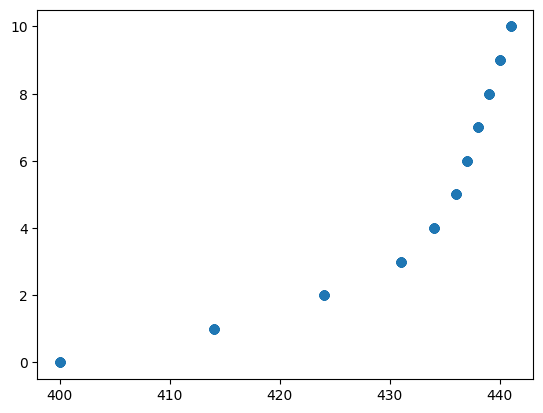

In [247]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(results.loc[:,"Total Patients Served"].values, results.loc[:,"Number of over staffed events"].values)

plt.show()